<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-01-12 15:56:09--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  52.7MB/s    in 2.9s    

2026-01-12 15:56:12 (52.7 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



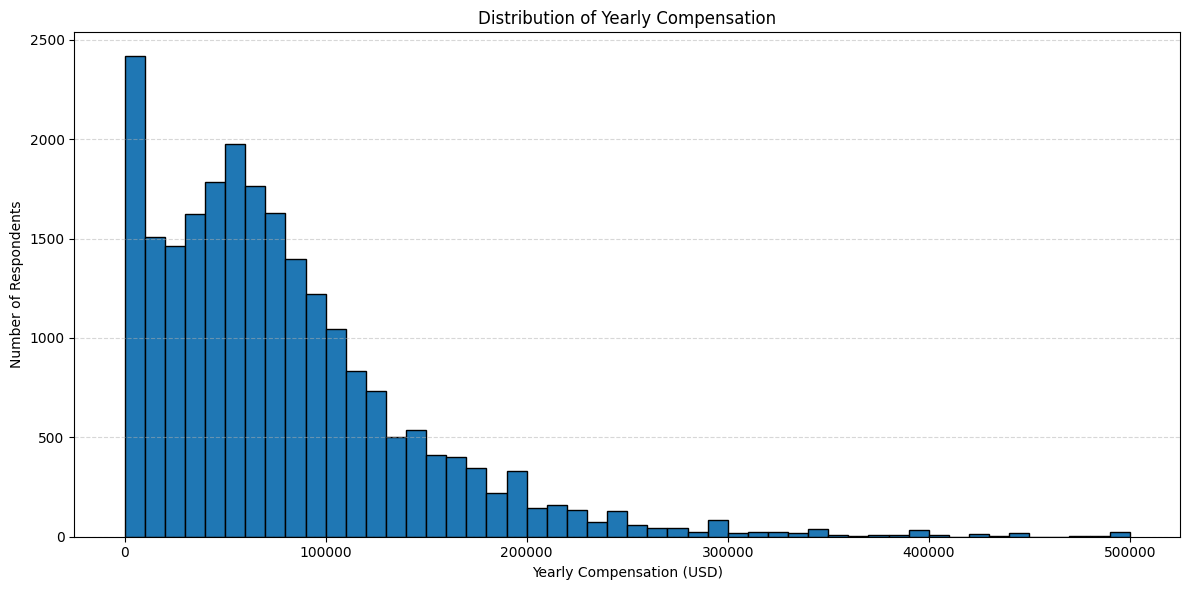

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Filter valid compensation values
df_filtered = df['ConvertedCompYearly'].dropna()

# Optional: Remove extreme outliers for better visualization (e.g., > 500k USD)
df_filtered = df_filtered[df_filtered <= 500000]

# Step 2: Plot histogram
plt.figure(figsize=(12,6))
plt.hist(df_filtered, bins=50, color='#1f77b4', edgecolor='black')
plt.title('Distribution of Yearly Compensation')
plt.xlabel('Yearly Compensation (USD)')
plt.ylabel('Number of Respondents')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



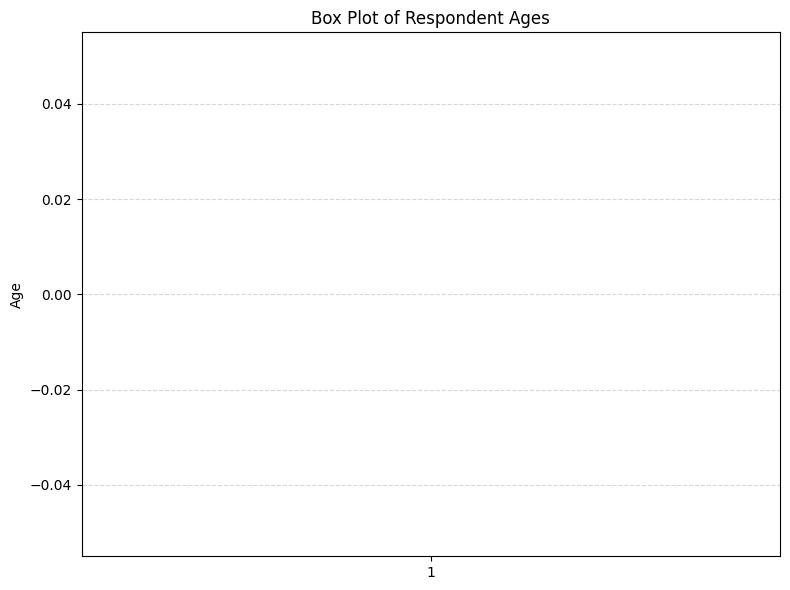

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Convert Age to numeric, non-numeric entries become NaN
df['Age_numeric'] = pd.to_numeric(df['Age'], errors='coerce')

# Step 2: Drop missing or invalid age values
age_data = df['Age_numeric'].dropna()

# Step 3: Plot box plot
plt.figure(figsize=(8,6))
plt.boxplot(age_data, patch_artist=True, boxprops=dict(facecolor='#ff7f0e', color='#ff7f0e'),
            medianprops=dict(color='black'), whiskerprops=dict(color='#ff7f0e'),
            capprops=dict(color='#ff7f0e'))
plt.title('Box Plot of Respondent Ages')
plt.ylabel('Age')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



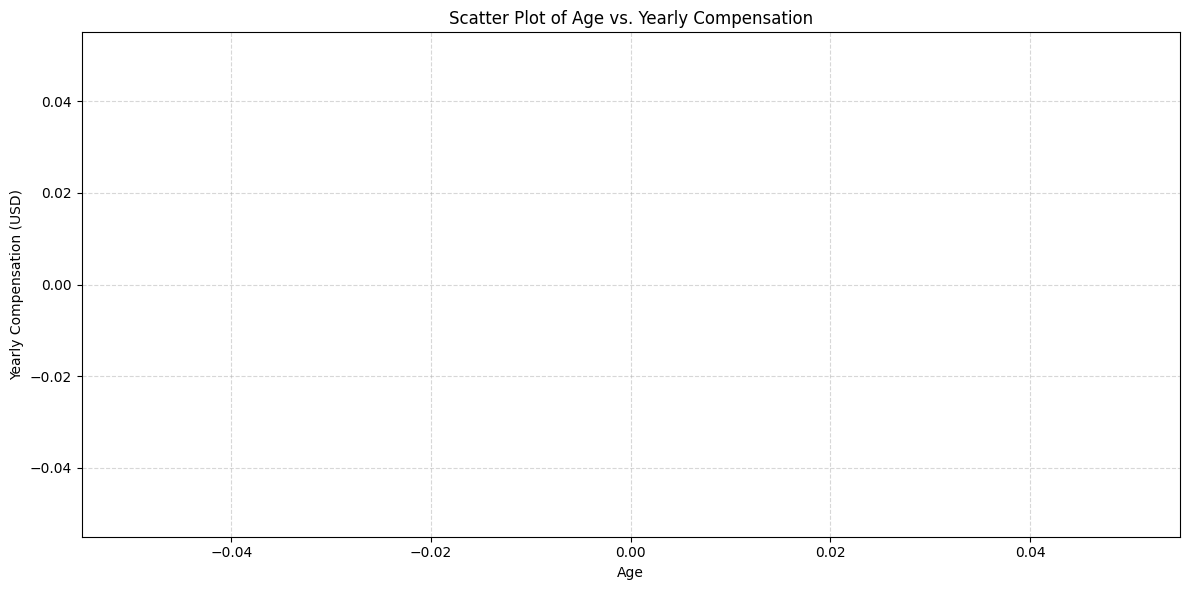

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Convert Age to numeric (if not already done)
df['Age_numeric'] = pd.to_numeric(df['Age'], errors='coerce')

# Step 2: Filter rows with valid Age and ConvertedCompYearly
df_filtered = df[['Age_numeric', 'ConvertedCompYearly']].dropna()

# Optional: Remove extreme outliers for better visualization (e.g., > 500k USD)
df_filtered = df_filtered[df_filtered['ConvertedCompYearly'] <= 500000]

# Step 3: Plot scatter plot
plt.figure(figsize=(12,6))
plt.scatter(df_filtered['Age_numeric'], df_filtered['ConvertedCompYearly'], 
            alpha=0.6, color='#1f77b4', edgecolors='w', s=50)
plt.title('Scatter Plot of Age vs. Yearly Compensation')
plt.xlabel('Age')
plt.ylabel('Yearly Compensation (USD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


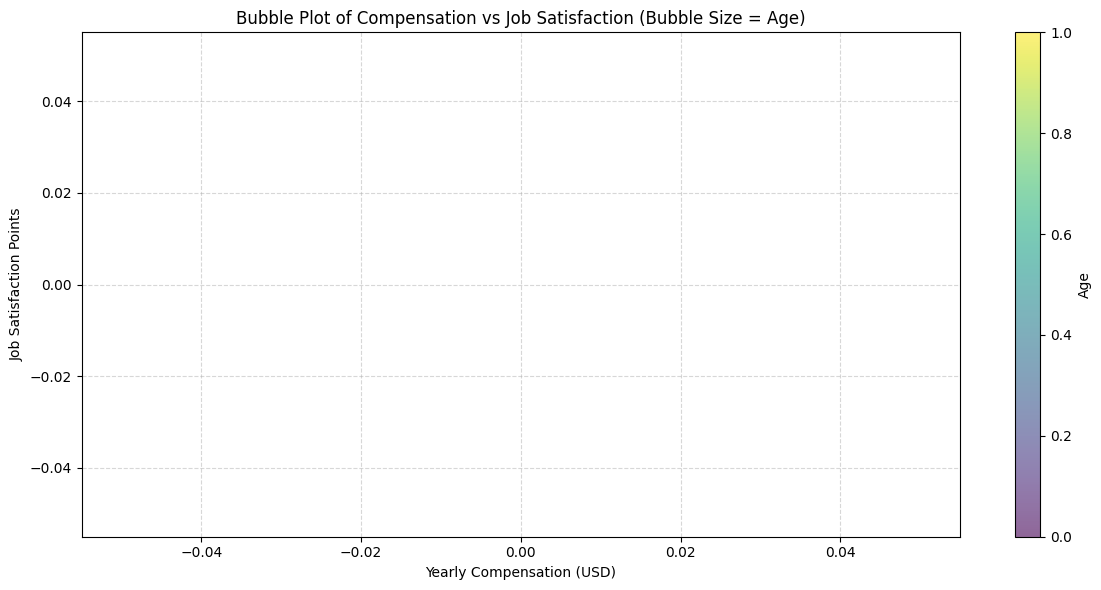

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Convert Age to numeric
df['Age_numeric'] = pd.to_numeric(df['Age'], errors='coerce')

# Step 2: Filter rows with valid values
df_filtered = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Age_numeric']].dropna()

# Optional: Remove extreme outliers for compensation
df_filtered = df_filtered[df_filtered['ConvertedCompYearly'] <= 500000]

# Step 3: Scale bubble sizes for plotting (so bubbles are not too large)
bubble_size = df_filtered['Age_numeric'] * 5  # multiply by a factor for better visibility

# Step 4: Plot bubble chart
plt.figure(figsize=(12,6))
scatter = plt.scatter(
    df_filtered['ConvertedCompYearly'],
    df_filtered['JobSatPoints_6'],
    s=bubble_size,
    alpha=0.6,
    c=df_filtered['Age_numeric'],  # color by age
    cmap='viridis',
    edgecolors='w',
    linewidth=0.5
)

plt.title('Bubble Plot of Compensation vs Job Satisfaction (Bubble Size = Age)')
plt.xlabel('Yearly Compensation (USD)')
plt.ylabel('Job Satisfaction Points')
plt.colorbar(scatter, label='Age')  # show age in color bar
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



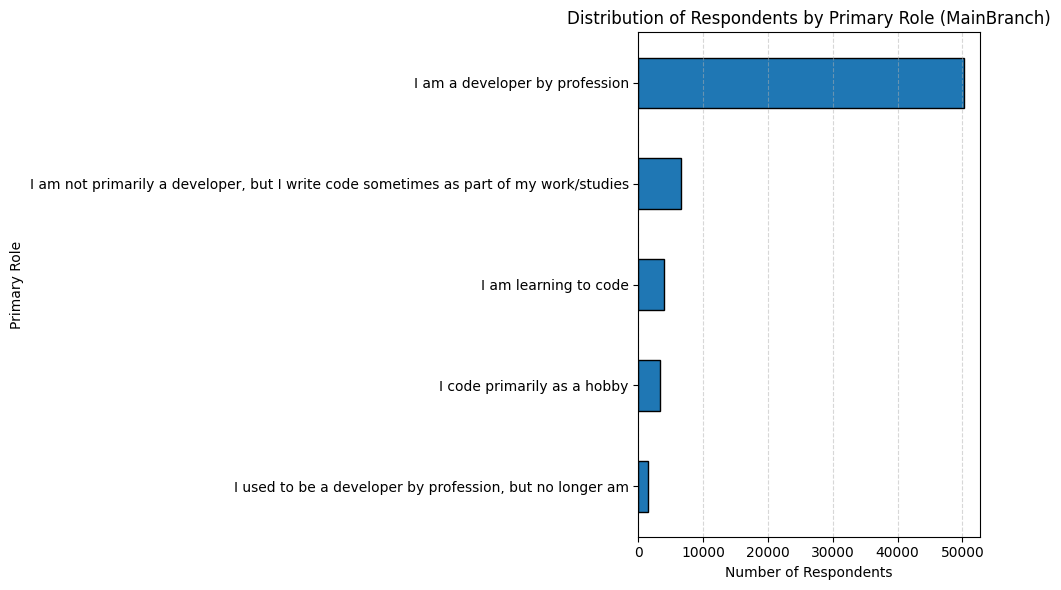

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Filter out missing MainBranch values
main_branch_counts = df['MainBranch'].dropna().value_counts()

# Step 2: Plot horizontal bar chart
plt.figure(figsize=(10,6))
main_branch_counts.plot(kind='barh', color='#1f77b4', edgecolor='black')

plt.title('Distribution of Respondents by Primary Role (MainBranch)')
plt.xlabel('Number of Respondents')
plt.ylabel('Primary Role')
plt.gca().invert_yaxis()  # Optional: largest bar on top
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



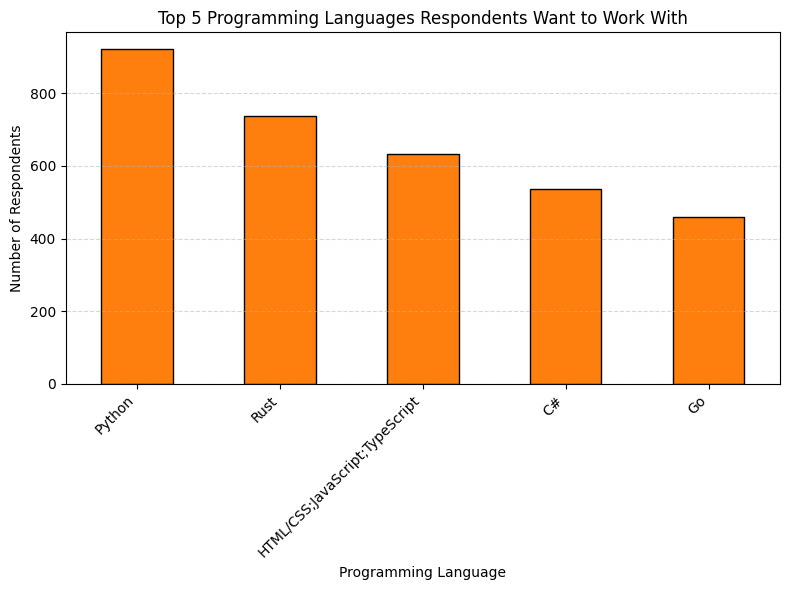

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Filter out missing values
lang_counts = df['LanguageWantToWorkWith'].dropna().value_counts()

# Step 2: Select top 5 languages
top5_langs = lang_counts.nlargest(5)

# Step 3: Plot vertical bar chart
plt.figure(figsize=(8,6))
top5_langs.plot(kind='bar', color='#ff7f0e', edgecolor='black')

plt.title('Top 5 Programming Languages Respondents Want to Work With')
plt.xlabel('Programming Language')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Convert Age to numeric
df['Age_numeric'] = pd.to_numeric(df['Age'], errors='coerce')

# Step 2: Filter valid rows
df_filtered = df[['Age_numeric', 'JobSatPoints_6', 'JobSatPoints_7']].dropna()

# Check if we have any data
if df_filtered.empty:
    print("No valid data available for Age and JobSatPoints columns!")
else:
    # Step 3: Group by Age and calculate median
    median_jobsat = df_filtered.groupby('Age_numeric')[['JobSatPoints_6', 'JobSatPoints_7']].median()
    
    # Additional check
    if median_jobsat.empty:
        print("No data after grouping by Age_numeric!")
    else:
        # Step 4: Plot stacked bar chart
        median_jobsat.plot(kind='bar', stacked=True, figsize=(12,6), color=['#1f77b4', '#ff7f0e'])
        plt.title('Median Job Satisfaction Points by Age Group')
        plt.xlabel('Age')
        plt.ylabel('Median Job Satisfaction Points')
        plt.legend(title='Metric', labels=['JobSatPoints_6', 'JobSatPoints_7'])
        plt.xticks(rotation=0)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()


No valid data available for Age and JobSatPoints columns!


##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



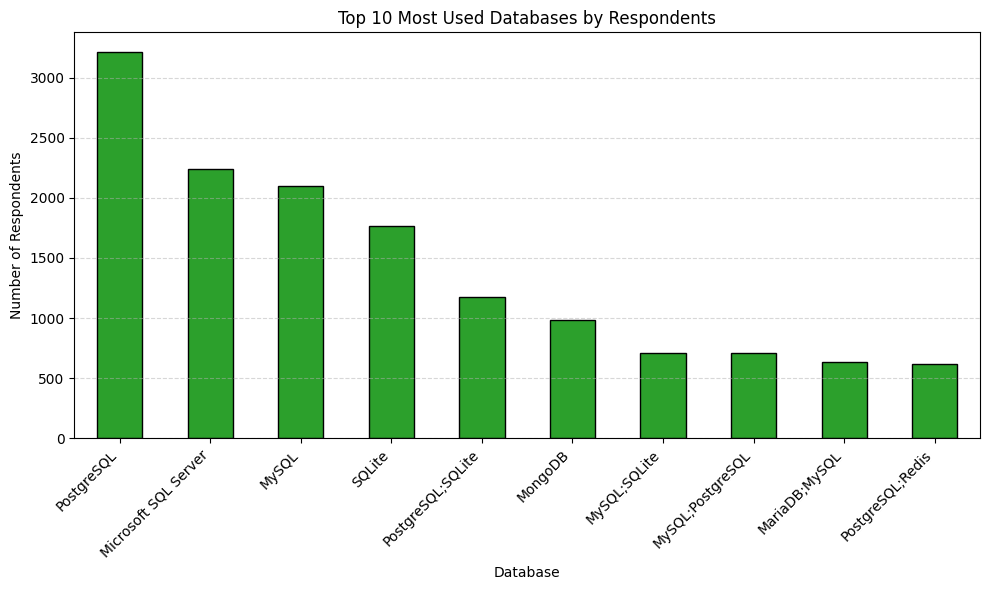

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Filter out missing values
db_counts = df['DatabaseHaveWorkedWith'].dropna().value_counts()

# Step 2: Select top 10 databases for clarity
top_dbs = db_counts.nlargest(10)

# Step 3: Plot bar chart
plt.figure(figsize=(10,6))
top_dbs.plot(kind='bar', color='#2ca02c', edgecolor='black')

plt.title('Top 10 Most Used Databases by Respondents')
plt.xlabel('Database')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



/tmp/ipykernel_1744/4031645931.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_comp = df_filtered.groupby('AgeGroup')['ConvertedCompYearly'].median()


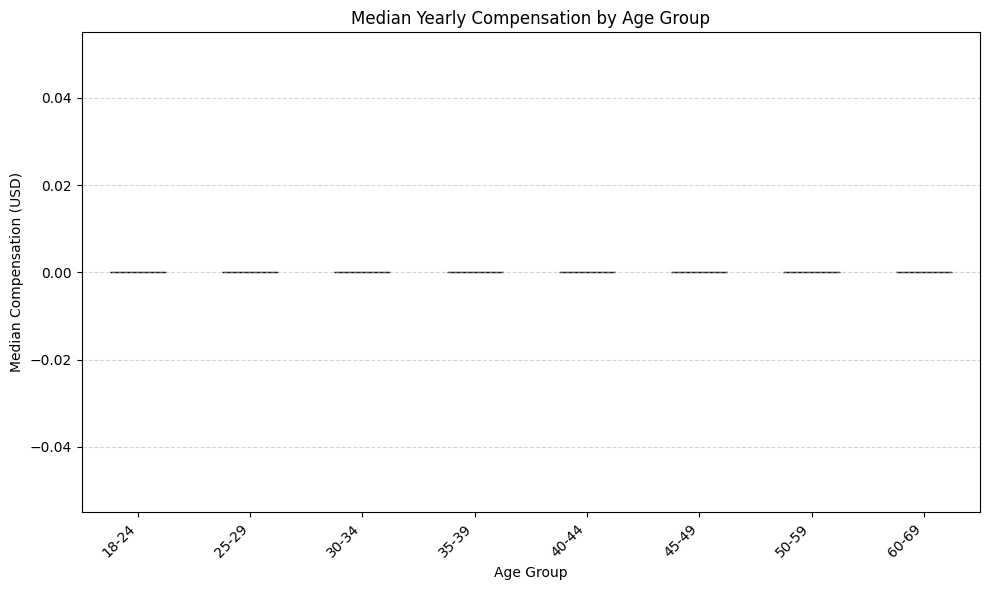

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Convert Age to numeric
df['Age_numeric'] = pd.to_numeric(df['Age'], errors='coerce')

# Step 2: Drop rows with missing Age or ConvertedCompYearly
df_filtered = df[['Age_numeric', 'ConvertedCompYearly']].dropna()

# Step 3: Create age groups (bins) for grouping
bins = [18, 25, 30, 35, 40, 45, 50, 60, 70]
labels = ['18-24','25-29','30-34','35-39','40-44','45-49','50-59','60-69']
df_filtered['AgeGroup'] = pd.cut(df_filtered['Age_numeric'], bins=bins, labels=labels, right=False)

# Step 4: Calculate median compensation for each age group
median_comp = df_filtered.groupby('AgeGroup')['ConvertedCompYearly'].median()

# Step 5: Plot grouped bar chart
plt.figure(figsize=(10,6))
median_comp.plot(kind='bar', color='#1f77b4', edgecolor='black')

plt.title('Median Yearly Compensation by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Compensation (USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



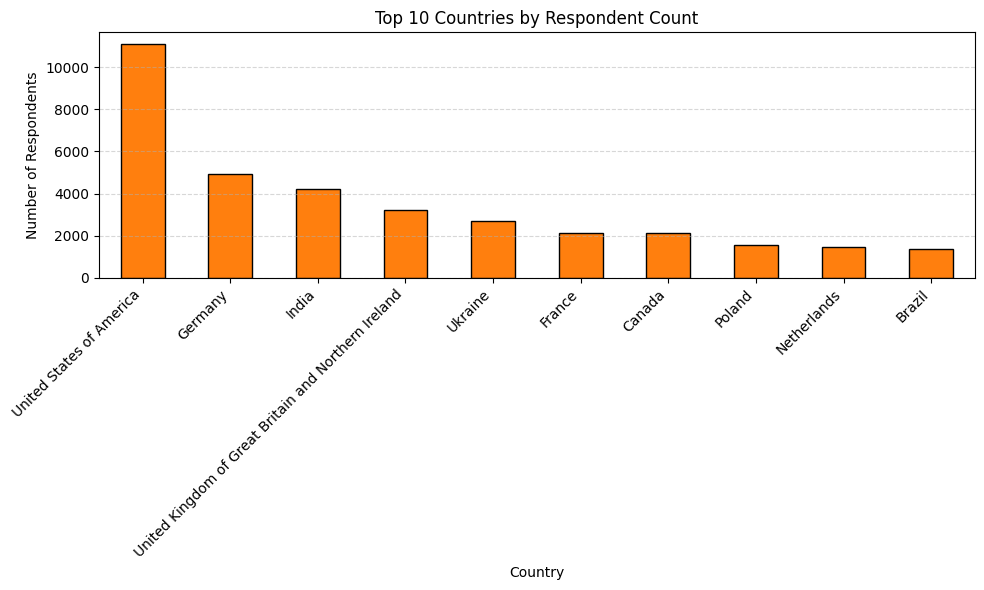

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Filter out missing Country values
country_counts = df['Country'].dropna().value_counts()

# Step 2: Select top 10 countries for clarity
top_countries = country_counts.nlargest(10)

# Step 3: Plot bar chart
plt.figure(figsize=(10,6))
top_countries.plot(kind='bar', color='#ff7f0e', edgecolor='black')

plt.title('Top 10 Countries by Respondent Count')
plt.xlabel('Country')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
